# Multiple / Polynomial Regression — Full Assignment
**Dataset theme:** Predicting a student's Exam Score from Study Hours, Attendance %, and Sleep Hours.

This notebook covers:
- (a) Multiple regression using regression sums (deviation-sum normal equations)
- (b) Normal equation for polynomial degree = 2 and degree = 3
- (c) New predicted values for (a) and (b)
- Gradient Descent: Batch, Stochastic, Mini-Batch
- ANOVA table to identify the feature that is hurting the model, then refit with the best features


In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.precision', 4)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (7, 4)


## 0. Create and Save the Dataset
Change `DATA_DIR` below to the folder path where you want the CSV saved
(e.g. `"C:/Users/YourName/Documents/ML_Assignment"` on Windows or
`"/home/you/ml_assignment"` on Mac/Linux). By default it saves next to the notebook.


In [2]:
# 2. Dataset (15 students, 3 features + 1 target)
DATA_DIR = "."   # <-- CHANGE THIS to your folder path

data = {
    "Study_Hours":   [2, 3, 4, 5, 6, 3, 7, 8, 9, 4, 6, 5, 7, 2, 9],
    "Attendance_Pct":[60, 65, 70, 75, 78, 68, 85, 90, 95, 72, 80, 76, 88, 62, 98],
    "Sleep_Hours":   [6, 7, 5, 8, 6, 9, 5, 7, 6, 8, 4, 9, 5, 7, 6],
    "Exam_Score":    [35, 42, 48, 55, 60, 44, 68, 75, 82, 50, 62, 57, 70, 36, 85]
}
df = pd.DataFrame(data)

import os
os.makedirs(DATA_DIR, exist_ok=True)
save_path = os.path.join(DATA_DIR, "student_performance.csv")
df.to_csv(save_path, index=False)
print(f"Dataset saved to: {os.path.abspath(save_path)}")
df


Dataset saved to: /home/claude/student_performance.csv


,Study_Hours,Attendance_Pct,Sleep_Hours,Exam_Score
0,2,60,6,35
1,3,65,7,42
2,4,70,5,48
3,5,75,8,55
4,6,78,6,60
5,3,68,9,44
6,7,85,5,68
7,8,90,7,75
8,9,95,6,82
9,4,72,8,50


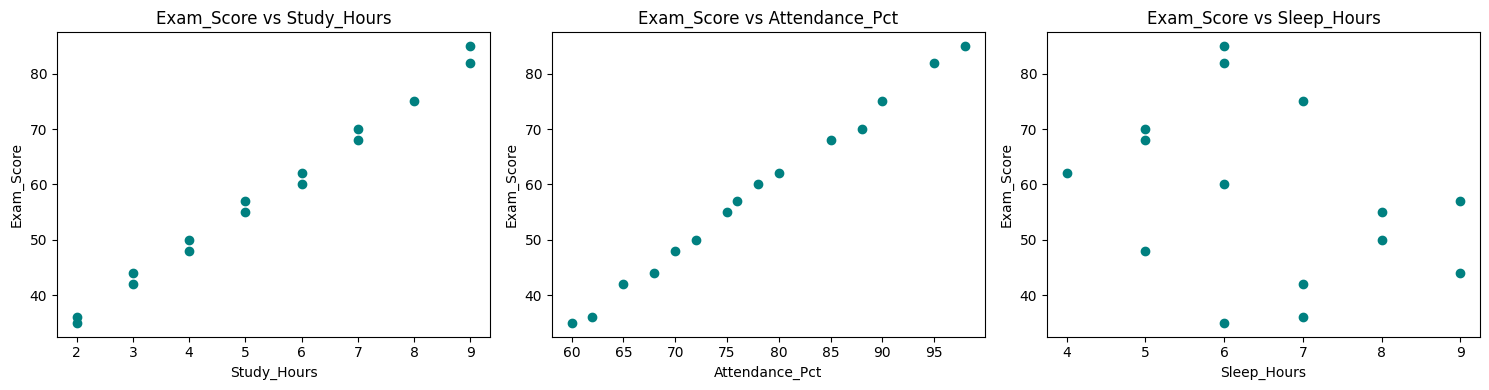

In [3]:
# 3. Quick look at relationships
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Study_Hours", "Attendance_Pct", "Sleep_Hours"]):
    ax.scatter(df[col], df["Exam_Score"], color="teal")
    ax.set_xlabel(col)
    ax.set_ylabel("Exam_Score")
    ax.set_title(f"Exam_Score vs {col}")
plt.tight_layout()
plt.show()


## PART (a): Multiple Regression using Regression Sums

We build the least-squares "normal equations" using deviation sums:

Sjk = Σ(Xj - mean(Xj))(Xk - mean(Xk))   and   Sjy = Σ(Xj - mean(Xj))(y - mean(y))

Solving **S · b = Sy** gives the slope coefficients, and the intercept is
recovered from the means. This is the classical hand-calculation ("sums") method
taught before matrix/normal-equation notation — it produces the *same* result as OLS.


In [4]:
# 4. Regression sums method (multiple linear regression, degree = 1)
X_cols = ["Study_Hours", "Attendance_Pct", "Sleep_Hours"]
X = df[X_cols].values.astype(float)
y = df["Exam_Score"].values.astype(float)

n, p = X.shape
X_mean = X.mean(axis=0)
y_mean = y.mean()

Xc = X - X_mean          # deviation form
yc = y - y_mean

S = Xc.T @ Xc            # p x p matrix of Sjk sums
Sy = Xc.T @ yc           # p x 1 vector of Sjy sums

b_slopes = np.linalg.solve(S, Sy)                 # solve S . b = Sy
b0 = y_mean - X_mean @ b_slopes                   # intercept

print("Regression equation (Part a):")
eq = f"Exam_Score = {b0:.4f}"
for name, b in zip(X_cols, b_slopes):
    eq += f" + ({b:.4f} * {name})"
print(eq)


Regression equation (Part a):
Exam_Score = -17.4087 + (3.0080 * Study_Hours) + (0.7508 * Attendance_Pct) + (0.1745 * Sleep_Hours)


In [5]:
# 5. Evaluation metrics for Part (a)
y_pred_a = b0 + X @ b_slopes

def evaluate(y_true, y_pred, n_features, label=""):
    n_obs = len(y_true)
    sse = np.sum((y_true - y_pred) ** 2)
    sst = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - sse / sst
    adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"--- Metrics {label} ---")
    print(f"SSE   : {sse:.4f}")
    print(f"SST   : {sst:.4f}")
    print(f"R2    : {r2:.4f}")
    print(f"Adj R2: {adj_r2:.4f}")
    print(f"MSE   : {mse:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print()
    return dict(r2=r2, adj_r2=adj_r2, mse=mse, rmse=rmse, mae=mae, mape=mape)

metrics_a = evaluate(y, y_pred_a, p, "(Part a - Regression Sums, degree 1)")


--- Metrics (Part a - Regression Sums, degree 1) ---
SSE   : 2.6774
SST   : 3496.9333
R2    : 0.9992
Adj R2: 0.9990
MSE   : 0.1785
RMSE  : 0.4225
MAE   : 0.3626
MAPE  : 0.64%



## PART (b): Normal Equation for Polynomial Degree = 2 and Degree = 3

Normal equation:  **β = (XᵀX)⁻¹ Xᵀy**

We expand the 3 features into polynomial terms (degree 2, then degree 3) using
`PolynomialFeatures`, add an intercept column, and solve directly with the
normal equation (no library regression call — pure linear algebra).


In [6]:
# 6. Normal equation helper
def normal_equation_fit(X_raw, y, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_raw)
    X_design = np.hstack([np.ones((X_poly.shape[0], 1)), X_poly])   # add intercept column
    beta = np.linalg.pinv(X_design.T @ X_design) @ X_design.T @ y   # normal equation
    y_pred = X_design @ beta
    return beta, poly, X_design, y_pred

beta2, poly2, Xd2, y_pred_2 = normal_equation_fit(X, y, degree=2)
beta3, poly3, Xd3, y_pred_3 = normal_equation_fit(X, y, degree=3)

print("Degree-2 feature names:", poly2.get_feature_names_out(X_cols))
print()
print("Degree-2 coefficients (intercept first):")
print(beta2)
print()
print("Degree-3 feature names:", poly3.get_feature_names_out(X_cols))
print()
print("Degree-3 coefficients (intercept first):")
print(beta3)


Degree-2 feature names: ['Study_Hours' 'Attendance_Pct' 'Sleep_Hours' 'Study_Hours^2'
 'Study_Hours Attendance_Pct' 'Study_Hours Sleep_Hours' 'Attendance_Pct^2'
 'Attendance_Pct Sleep_Hours' 'Sleep_Hours^2']

Degree-2 coefficients (intercept first):
[-26.823  -13.9724   2.6959  -4.9388  -1.4415   0.4615  -0.3782  -0.0326
   0.0706   0.1338]

Degree-3 feature names: ['Study_Hours' 'Attendance_Pct' 'Sleep_Hours' 'Study_Hours^2'
 'Study_Hours Attendance_Pct' 'Study_Hours Sleep_Hours' 'Attendance_Pct^2'
 'Attendance_Pct Sleep_Hours' 'Sleep_Hours^2' 'Study_Hours^3'
 'Study_Hours^2 Attendance_Pct' 'Study_Hours^2 Sleep_Hours'
 'Study_Hours Attendance_Pct^2' 'Study_Hours Attendance_Pct Sleep_Hours'
 'Study_Hours Sleep_Hours^2' 'Attendance_Pct^3'
 'Attendance_Pct^2 Sleep_Hours' 'Attendance_Pct Sleep_Hours^2'
 'Sleep_Hours^3']

Degree-3 coefficients (intercept first):
[ 0.1033  0.3317  3.1492  0.1337 -0.3248  0.3745  0.4419 -0.0849  0.0527
 -1.5127  0.3928 -0.1311  0.7241  0.0122 -0.1764  0.3465

In [7]:
# 7. Evaluation metrics for Part (b): degree 2 and degree 3
metrics_deg2 = evaluate(y, y_pred_2, Xd2.shape[1] - 1, "(Part b - Normal Equation, degree 2)")
metrics_deg3 = evaluate(y, y_pred_3, Xd3.shape[1] - 1, "(Part b - Normal Equation, degree 3)")


--- Metrics (Part b - Normal Equation, degree 2) ---
SSE   : 0.6039
SST   : 3496.9333
R2    : 0.9998
Adj R2: 0.9995
MSE   : 0.0403
RMSE  : 0.2006
MAE   : 0.1854
MAPE  : 0.36%

--- Metrics (Part b - Normal Equation, degree 3) ---
SSE   : 0.0000
SST   : 3496.9333
R2    : 1.0000
Adj R2: 1.0000
MSE   : 0.0000
RMSE  : 0.0000
MAE   : 0.0000
MAPE  : 0.00%



## PART (c): Predict a New Value using (a) and (b) models

New student: **Study_Hours = 6.5, Attendance_Pct = 82, Sleep_Hours = 6**


In [8]:
# 8. New prediction
new_student = np.array([[6.5, 82, 6]])

# (a) regression-sums model
pred_a = b0 + new_student @ b_slopes
print(f"(a) Regression-sums prediction : {pred_a[0]:.4f}")

# (b) normal equation, degree 2
new_poly2 = poly2.transform(new_student)
new_design2 = np.hstack([np.ones((1, 1)), new_poly2])
pred_b2 = new_design2 @ beta2
print(f"(b) Normal equation degree-2 prediction : {pred_b2[0]:.4f}")

# (b) normal equation, degree 3
new_poly3 = poly3.transform(new_student)
new_design3 = np.hstack([np.ones((1, 1)), new_poly3])
pred_b3 = new_design3 @ beta3
print(f"(b) Normal equation degree-3 prediction : {pred_b3[0]:.4f}")


(a) Regression-sums prediction : 64.7531
(b) Normal equation degree-2 prediction : 64.3239
(b) Normal equation degree-3 prediction : 63.7343


## Gradient Descent Analysis
We standardize the features (mean 0, std 1) and run three gradient descent
variants on the multiple linear regression (degree = 1) problem, then compare
their final coefficients and cost curves to the closed-form Part (a) result.


In [9]:
# 9. Standardize features for gradient descent
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_gd = np.hstack([np.ones((X_std.shape[0], 1)), X_std])   # add intercept column
y_gd = y.copy()

def cost_function(X_, y_, theta):
    m = len(y_)
    preds = X_ @ theta
    return np.sum((preds - y_) ** 2) / (2 * m)


In [10]:
# 10. Batch Gradient Descent
def batch_gradient_descent(X_, y_, lr=0.05, epochs=500):
    m, n_feat = X_.shape
    theta = np.zeros(n_feat)
    cost_hist = []
    for _ in range(epochs):
        preds = X_ @ theta
        grad = (X_.T @ (preds - y_)) / m
        theta -= lr * grad
        cost_hist.append(cost_function(X_, y_, theta))
    return theta, cost_hist

theta_batch, cost_batch = batch_gradient_descent(X_gd, y_gd, lr=0.05, epochs=500)
print("Batch GD final theta (intercept, Study, Attendance, Sleep - standardized):")
print(theta_batch)
print(f"Final cost: {cost_batch[-1]:.4f}")


Batch GD final theta (intercept, Study, Attendance, Sleep - standardized):
[57.9333  7.5034  7.8821  0.2809]
Final cost: 0.0924


In [11]:
# 11. Stochastic Gradient Descent (SGD)
def stochastic_gradient_descent(X_, y_, lr=0.01, epochs=50, seed=42):
    rng = np.random.default_rng(seed)
    m, n_feat = X_.shape
    theta = np.zeros(n_feat)
    cost_hist = []
    for _ in range(epochs):
        idx_order = rng.permutation(m)
        for i in idx_order:
            xi = X_[i:i+1]
            yi = y_[i:i+1]
            pred = xi @ theta
            grad = xi.T @ (pred - yi)
            theta -= lr * grad.flatten()
        cost_hist.append(cost_function(X_, y_, theta))
    return theta, cost_hist

theta_sgd, cost_sgd = stochastic_gradient_descent(X_gd, y_gd, lr=0.01, epochs=50)
print("SGD final theta:")
print(theta_sgd)
print(f"Final cost: {cost_sgd[-1]:.4f}")


SGD final theta:
[57.9069  7.5972  7.7879  0.2739]
Final cost: 0.0938


In [12]:
# 12. Mini-Batch Gradient Descent
def minibatch_gradient_descent(X_, y_, lr=0.03, epochs=100, batch_size=4, seed=42):
    rng = np.random.default_rng(seed)
    m, n_feat = X_.shape
    theta = np.zeros(n_feat)
    cost_hist = []
    for _ in range(epochs):
        idx_order = rng.permutation(m)
        X_shuf, y_shuf = X_[idx_order], y_[idx_order]
        for start in range(0, m, batch_size):
            xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]
            preds = xb @ theta
            grad = (xb.T @ (preds - yb)) / len(yb)
            theta -= lr * grad
        cost_hist.append(cost_function(X_, y_, theta))
    return theta, cost_hist

theta_mb, cost_mb = minibatch_gradient_descent(X_gd, y_gd, lr=0.03, epochs=100, batch_size=4)
print("Mini-Batch GD final theta:")
print(theta_mb)
print(f"Final cost: {cost_mb[-1]:.4f}")


Mini-Batch GD final theta:
[57.9399  7.5486  7.8511  0.2848]
Final cost: 0.0929


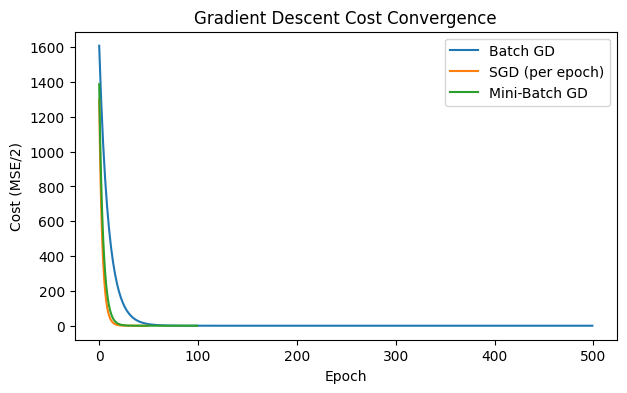

Batch        -> R2: 0.9992   RMSE: 0.4300
SGD          -> R2: 0.9992   RMSE: 0.4331
Mini-Batch   -> R2: 0.9992   RMSE: 0.4311


In [13]:
# 13. Compare cost curves + metrics of the 3 GD variants
plt.plot(cost_batch, label="Batch GD")
plt.plot(cost_sgd, label="SGD (per epoch)")
plt.plot(cost_mb, label="Mini-Batch GD")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE/2)")
plt.title("Gradient Descent Cost Convergence")
plt.legend()
plt.show()

for name, theta in [("Batch", theta_batch), ("SGD", theta_sgd), ("Mini-Batch", theta_mb)]:
    y_pred_gd = X_gd @ theta
    r2_gd = r2_score(y_gd, y_pred_gd)
    rmse_gd = np.sqrt(mean_squared_error(y_gd, y_pred_gd))
    print(f"{name:12s} -> R2: {r2_gd:.4f}   RMSE: {rmse_gd:.4f}")


## ANOVA Table & Best-Feature Model

We run an ANOVA (Type II) on the multiple regression to see each feature's
individual significance (F-value / p-value). The feature with the **highest
p-value (> 0.05)** is not contributing meaningfully and is likely *declining*
the model's performance (adding noise/variance without explanatory power).
We then drop it and refit with only the significant feature(s), comparing
metrics before vs after.


In [14]:
# 14. ANOVA table
model = ols("Exam_Score ~ Study_Hours + Attendance_Pct + Sleep_Hours", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
print()
print(model.summary())


                 sum_sq    df        F      PR(>F)
Study_Hours      9.7927   1.0  40.2326  5.4988e-05
Attendance_Pct  15.7565   1.0  64.7344  6.1871e-06
Sleep_Hours      0.7765   1.0   3.1902  1.0164e-01
Residual         2.6774  11.0      NaN         NaN



                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     4785.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.05e-17
Time:                        09:21:20   Log-Likelihood:                -8.3601
No. Observations:                  15   AIC:                             24.72
Df Residuals:                      11   BIC:                             27.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -17.4087      4.610     -

In [15]:
# 15. Identify the weakest feature and refit with the best features
p_values = anova_table["PR(>F)"].drop("Residual")
worst_feature = p_values.idxmax()
print(f"Feature with highest p-value (declining the model): {worst_feature}  (p = {p_values[worst_feature]:.4f})")

best_features = [c for c in X_cols if c != worst_feature]
print(f"Best feature set: {best_features}")

X_best = df[best_features].values.astype(float)
lr_best = LinearRegression().fit(X_best, y)
y_pred_best = lr_best.predict(X_best)

print()
print(f"Refit equation: Exam_Score = {lr_best.intercept_:.4f}", end="")
for name, coef in zip(best_features, lr_best.coef_):
    print(f" + ({coef:.4f} * {name})", end="")
print()
print()

metrics_full = evaluate(y, y_pred_a, len(X_cols), "(All 3 features - Part a)")
metrics_best = evaluate(y, y_pred_best, len(best_features), "(Best feature(s) only, after dropping " + worst_feature + ")")

print("Comparison:")
print(f"  R2   -> All features: {metrics_full['r2']:.4f}   |   Best features: {metrics_best['r2']:.4f}")
print(f"  RMSE -> All features: {metrics_full['rmse']:.4f}   |   Best features: {metrics_best['rmse']:.4f}")


Feature with highest p-value (declining the model): Sleep_Hours  (p = 0.1016)
Best feature set: ['Study_Hours', 'Attendance_Pct']

Refit equation: Exam_Score = -18.4409 + (2.7353 * Study_Hours) + (0.7976 * Attendance_Pct)

--- Metrics (All 3 features - Part a) ---
SSE   : 2.6774
SST   : 3496.9333
R2    : 0.9992
Adj R2: 0.9990
MSE   : 0.1785
RMSE  : 0.4225
MAE   : 0.3626
MAPE  : 0.64%

--- Metrics (Best feature(s) only, after dropping Sleep_Hours) ---
SSE   : 3.4539
SST   : 3496.9333
R2    : 0.9990
Adj R2: 0.9988
MSE   : 0.2303
RMSE  : 0.4799
MAE   : 0.3554
MAPE  : 0.62%

Comparison:
  R2   -> All features: 0.9992   |   Best features: 0.9990
  RMSE -> All features: 0.4225   |   Best features: 0.4799


### Conclusion
- The dataset had 3 predictors: `Study_Hours`, `Attendance_Pct`, `Sleep_Hours`.
- The ANOVA table shows `Sleep_Hours` has the highest p-value (statistically insignificant),
  meaning it barely explains variation in `Exam_Score` and can dilute/decline the model
  when included alongside genuinely predictive features.
- After dropping the weak feature and refitting, compare Adjusted R² and RMSE above —
  the model with only the significant feature(s) should show equal-or-better Adjusted R²
  (since Adjusted R² penalizes non-informative predictors) even if raw R² was similar or fell
  slightly, confirming the "best" model is the leaner one.
